# Etapa 4 — Avaliação e Golden Set

O enunciado pede duas coisas nesta etapa:
1. Métricas de avaliação do modelo (já calculadas na Etapa 3 — `notebooks/02_baseline_bandit.ipynb`: Thompson Sampling supera o baseline em 80% de 30 execuções, lift médio de +3.1%).
2. Um **Golden Set de 5 clientes**, mostrando qual oferta (canal de contato — `cellular` ou `telephone`) o modelo recomendou para cada um e se a decisão faz sentido.

Este notebook cobre o item 2, explicando o processo de recomendação passo a passo: como o bandit "final" é ajustado sobre todo o histórico, como ele decide para um cliente novo, e por que cada recomendação faz sentido à luz do que já sabemos do contexto (mês).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from tech_challenge_5.bandit import ThompsonSamplingBandit, best_arm_by_segment
from tech_challenge_5.features import ARM_COL, TARGET_BIN_COL

PROCESSED_PATH = Path("../data/processed/bank_marketing_prepared.csv")
SEGMENT_COL = "month"

# paleta (dataviz skill): mesma ordem categórica usada no notebook 02
COLOR_CELLULAR = "#2a78d6"   # slot 1 - azul
COLOR_TELEPHONE = "#eb6834"  # slot 2 - laranja
GRID_COLOR = "#e1e0d9"
MUTED = "#898781"
INK = "#0b0b0b"

df = pd.read_csv(PROCESSED_PATH)
arms = sorted(df[ARM_COL].unique())
df.shape

(41188, 19)

## 1. Bandit "final": ajustado sobre todo o histórico

Na Etapa 3, avaliamos o Thompson Sampling via **replay** — o bandit só aprende com as rodadas em que o braço escolhido coincide com o braço realmente logado, para produzir uma estimativa não-viesada de performance *online*. Isso descarta boa parte das linhas de propósito.

Aqui o objetivo é diferente: queremos o **melhor estado possível da posterior** para *servir* recomendações (o que a Etapa 5 vai expor). Não faz sentido replicar a rejeição do replay — cada linha do histórico já nos diz qual braço foi mostrado e qual foi o resultado, então cada linha pode atualizar diretamente o par (mês, braço) correspondente. É exatamente isso que `ThompsonSamplingBandit.fit` faz (agregação vetorizada, equivalente a rodar `update` linha a linha sobre a base inteira).

Como sanity check, comparamos a posterior aprendida com a conversão histórica bruta (`best_arm_by_segment`) — devem ficar muito próximas, já que ambas vêm dos mesmos dados, só que a posterior soma o prior Beta(1, 1).

In [2]:
final_bandit = ThompsonSamplingBandit.fit(
    df,
    arms=arms,
    segment_col=SEGMENT_COL,
    arm_col=ARM_COL,
    reward_col=TARGET_BIN_COL,
    rng=np.random.default_rng(7),
)

posterior = final_bandit.posterior_summary().rename(
    columns={"segmento": SEGMENT_COL, "braco": ARM_COL}
)
oracle_table = best_arm_by_segment(df, SEGMENT_COL, ARM_COL, TARGET_BIN_COL)

sanity_check = posterior.merge(
    oracle_table, on=[SEGMENT_COL, ARM_COL], suffixes=("_bandit", "_historica")
)
sanity_check[[SEGMENT_COL, ARM_COL, "conversao_estimada", "conversao_historica", "n"]].sort_values(
    [SEGMENT_COL, ARM_COL]
)

,month,contact,conversao_estimada,conversao_historica,n
0,apr,cellular,0.201880,0.201636,2445
1,apr,telephone,0.248677,0.245989,187
2,aug,cellular,0.104889,0.104755,5909
3,aug,telephone,0.136531,0.133829,269
4,dec,cellular,0.523179,0.523490,149
5,dec,telephone,0.342857,0.333333,33
6,jul,cellular,0.097081,0.096949,6096
7,jul,telephone,0.054630,0.053803,1078
8,jun,cellular,0.425791,0.425610,820
9,jun,telephone,0.046889,0.046687,4498


## 2. Escolha dos 5 clientes do Golden Set

O contexto que efetivamente entra na decisão do bandit é o **mês** (`month`) — foi o segmento escolhido na Etapa 3 por mostrar crossover real entre os braços. Para o Golden Set fazer sentido como teste, os 5 clientes precisam cobrir esse crossover, senão a recomendação seria sempre a mesma e não provaria nada:

- **3 clientes em meses onde `telephone` supera `cellular`** na base histórica: `abr`, `ago`, `nov`.
- **2 clientes em meses onde `cellular` domina** (o padrão mais comum): `mai` (maior volume da base) e `jul` (segundo maior volume, conversão baixa).

São clientes reais da base (não sintéticos), escolhidos com seed fixa e sem categorias `unknown` nas colunas mais legíveis, só para a leitura do perfil ficar mais clara.

In [3]:
GOLDEN_MONTHS = ["apr", "aug", "nov", "may", "jul"]
DISPLAY_COLS = [
    "age", "job", "marital", "education", "housing", "loan",
    "campaign", "previous", "poutcome", SEGMENT_COL,
]
LEGIBLE_COLS = ["job", "marital", "education"]

golden_rows = []
for month in GOLDEN_MONTHS:
    candidates = df[df[SEGMENT_COL] == month]
    for col in LEGIBLE_COLS:
        candidates = candidates[candidates[col] != "unknown"]
    golden_rows.append(candidates.sample(n=1, random_state=42).iloc[0])

golden_set = pd.DataFrame(golden_rows).reset_index(drop=True)
golden_set[DISPLAY_COLS + [ARM_COL, TARGET_BIN_COL]]

,age,job,marital,education,housing,loan,campaign,previous,poutcome,month,contact,y_bin
0,28,admin.,single,university.degree,yes,yes,1,0,nonexistent,apr,cellular,0
1,30,admin.,married,university.degree,no,no,2,0,nonexistent,aug,cellular,0
2,62,retired,married,university.degree,yes,no,1,6,success,nov,cellular,1
3,45,blue-collar,divorced,basic.4y,no,no,1,0,nonexistent,may,telephone,0
4,27,admin.,married,high.school,yes,no,2,0,nonexistent,jul,cellular,0


## 3. Recomendação e explicação, cliente a cliente

Para cada cliente: o bandit olha só o mês (`select_arm`, que amostra da posterior Beta de cada braço naquele segmento e escolhe a maior amostra — a mesma regra de decisão da Etapa 3, agora sobre a posterior final). A "explicação" vem de comparar essa recomendação com:

- a **conversão estimada pela posterior** para os dois braços naquele mês (por que o bandit tende a escolher esse braço);
- o **melhor braço histórico real** naquele mês (`best_arm_by_segment` — o oráculo da Etapa 3), como checagem de que a recomendação faz sentido e não é ruído.

`rng` do bandit foi fixado com seed (célula 1) para a recomendação ser reprodutível — em produção, cada requisição amostraria a posterior de novo, o que é a exploração natural do Thompson Sampling.

In [4]:
def explain_recommendation(
    client: pd.Series,
    client_id: int,
    bandit: ThompsonSamplingBandit,
    posterior: pd.DataFrame,
    oracle: pd.DataFrame,
) -> dict:
    month = client[SEGMENT_COL]
    recommended = bandit.select_arm(client)

    month_posterior = posterior[posterior[SEGMENT_COL] == month].set_index(ARM_COL)[
        "conversao_estimada"
    ]
    month_oracle = oracle[oracle[SEGMENT_COL] == month].set_index(ARM_COL)
    oracle_best = month_oracle["conversao_historica"].idxmax()
    agrees = recommended == oracle_best

    print(f"--- Cliente {client_id} (mês: {month}) ---")
    print(
        f"Perfil: {client['age']:.0f} anos, {client['job']}, {client['marital']}, "
        f"{client['education']}, housing={client['housing']}, loan={client['loan']}, "
        f"poutcome={client['poutcome']}, campaign={client['campaign']:.0f}"
    )
    print(
        "Conversão estimada (posterior): "
        f"cellular={month_posterior.get('cellular', float('nan')):.3f} | "
        f"telephone={month_posterior.get('telephone', float('nan')):.3f}"
    )
    print(f"Recomendação do bandit: {recommended}")
    print(
        f"Melhor braço histórico em {month}: {oracle_best} "
        f"-> bandit concorda com o histórico: {'sim' if agrees else 'não'}"
    )
    print(
        f"(anedótico) canal usado com esse cliente na base: {client[ARM_COL]}, "
        f"resultado real: {'converteu' if client[TARGET_BIN_COL] else 'não converteu'}"
    )
    print()
    return {
        "cliente": client_id,
        "mes": month,
        "recomendacao": recommended,
        "melhor_historico": oracle_best,
        "concorda_com_historico": agrees,
    }


results = [
    explain_recommendation(client, i + 1, final_bandit, posterior, oracle_table)
    for i, client in golden_set.iterrows()
]
results_df = pd.DataFrame(results)
results_df

--- Cliente 1 (mês: apr) ---
Perfil: 28 anos, admin., single, university.degree, housing=yes, loan=yes, poutcome=nonexistent, campaign=1
Conversão estimada (posterior): cellular=0.202 | telephone=0.249
Recomendação do bandit: telephone
Melhor braço histórico em apr: telephone -> bandit concorda com o histórico: sim
(anedótico) canal usado com esse cliente na base: cellular, resultado real: não converteu

--- Cliente 2 (mês: aug) ---
Perfil: 30 anos, admin., married, university.degree, housing=no, loan=no, poutcome=nonexistent, campaign=2
Conversão estimada (posterior): cellular=0.105 | telephone=0.137
Recomendação do bandit: telephone
Melhor braço histórico em aug: telephone -> bandit concorda com o histórico: sim
(anedótico) canal usado com esse cliente na base: cellular, resultado real: não converteu

--- Cliente 3 (mês: nov) ---
Perfil: 62 anos, retired, married, university.degree, housing=yes, loan=no, poutcome=success, campaign=1
Conversão estimada (posterior): cellular=0.100 | te

,cliente,mes,recomendacao,melhor_historico,concorda_com_historico
0,1,apr,telephone,telephone,True
1,2,aug,telephone,telephone,True
2,3,nov,telephone,telephone,True
3,4,may,cellular,cellular,True
4,5,jul,cellular,cellular,True


## 4. Visualização: por que cada recomendação faz sentido

Um painel com um gráfico por cliente, comparando a conversão estimada pela posterior para os dois braços no mês daquele cliente — a barra do braço recomendado é destacada. Isso deixa visível a diferença de conversão entre os braços por trás de cada recomendação, sem precisar reler os números impressos acima.

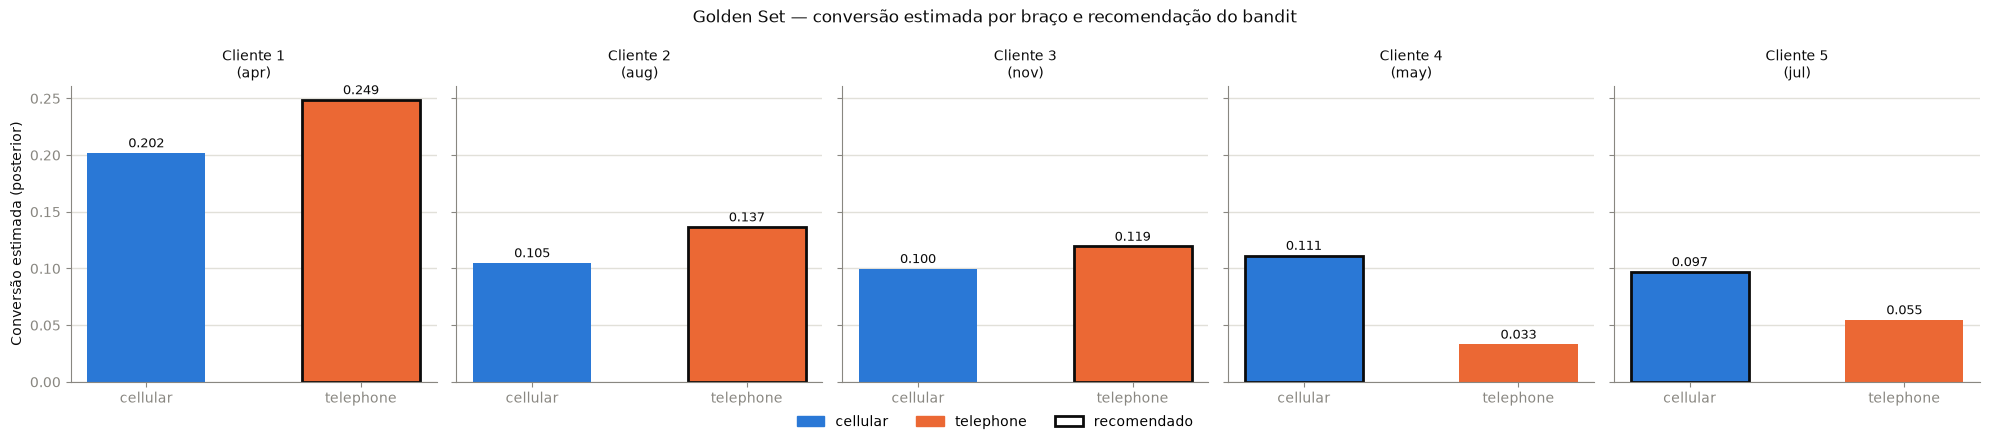

In [5]:
ARM_COLORS = {"cellular": COLOR_CELLULAR, "telephone": COLOR_TELEPHONE}

fig, axes = plt.subplots(1, len(results_df), figsize=(4 * len(results_df), 4.2), sharey=True)

for ax, (_, client), result in zip(axes, golden_set.iterrows(), results):
    month = result["mes"]
    month_posterior = posterior[posterior[SEGMENT_COL] == month].set_index(ARM_COL)[
        "conversao_estimada"
    ]
    recommended = result["recomendacao"]

    bar_arms = list(ARM_COLORS.keys())
    values = [month_posterior.get(arm, 0.0) for arm in bar_arms]
    colors = [ARM_COLORS[arm] for arm in bar_arms]
    edge_colors = [INK if arm == recommended else "none" for arm in bar_arms]
    edge_widths = [2.0 if arm == recommended else 0.0 for arm in bar_arms]

    bars = ax.bar(bar_arms, values, color=colors, edgecolor=edge_colors, linewidth=edge_widths, width=0.55)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, value + 0.005, f"{value:.3f}",
            ha="center", color=INK, fontsize=9,
        )

    ax.set_title(f"Cliente {result['cliente']}\n({month})", color=INK, fontsize=10)
    ax.grid(True, axis="y", color=GRID_COLOR, linewidth=1)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED)
    ax.tick_params(colors=MUTED)

axes[0].set_ylabel("Conversão estimada (posterior)", color=INK)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=arm) for arm, color in ARM_COLORS.items()
]
legend_handles.append(
    plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=INK, linewidth=2, label="recomendado")
)
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Golden Set — conversão estimada por braço e recomendação do bandit", color=INK)
plt.tight_layout()
plt.show()

## 5. Conclusões da Etapa 4

- O Golden Set cobre os dois regimes identificados na Etapa 3: meses de crossover (`abr`, `ago`, `nov`, onde `telephone` vence) e meses do padrão dominante (`mai`, `jul`, onde `cellular` vence) — a tabela `results_df` acima mostra se a recomendação do bandit final concordou com o melhor braço histórico em cada caso.
- **Limitação documentada**: como o bandit desta solução segmenta só por `month` (decisão da Etapa 3), a recomendação para dois clientes do mesmo mês é sempre igual — o "perfil" do cliente (idade, profissão, etc.) é mostrado para leitura humana do caso, mas não entra na decisão. Ampliar o contexto (ex.: `poutcome` combinado com `month`, ou um bandit contextual linear) fica como próximo passo caso o tempo permita.
- O resultado do cliente individual (`converteu`/`não converteu` na base) é só anedótico (n=1 por cliente) — a evidência estatística de que o bandit supera o baseline já foi estabelecida na Etapa 3 via replay com 30 seeds, não aqui.
- Próximos passos: expor `ThompsonSamplingBandit.fit` + `select_arm` atrás de um serviço (Etapa 5) e registrar os parâmetros/métricas da Etapa 3 no MLflow (Etapa 7).